# Shoaling across experiments: 2h vs 4h Episode Comparison

This notebook compares the current 24-episode, 2-hour analysis window against the full available recording window for 2026 shoaling-selection experiments. It focuses on bout-like (`02k20f`) and linear (`01k01f`) episode types, while keeping the episode filter easy to edit.

In [1]:
# Standard-library imports for paths, directory changes, and file pattern matching.
import os
import glob
from pathlib import Path

# Analysis and plotting libraries used throughout the notebook.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.stats.api as sms

# Keep notebook plotting explicit and make local module edits reload automatically.
%config InteractiveShellApp.pylab_import_all = False
%matplotlib inline
%reload_ext autoreload
%autoreload 2

# Make imports work whether the notebook is launched from the repo root or Analyses/.
cwd = Path.cwd()
REPO_DIR = cwd.parent if cwd.name == 'Analyses' else cwd
os.chdir(REPO_DIR)

# Project helpers: path splitting, paper-style plotting defaults, and the batch processor.
import functions.matrixUtilities_joh as mu
import functions.paperFigureProps as pfp
import models.experiment_set as es

# Set global figure aesthetics before any plots are created.
pfp.paper()
sns.set_context('talk')
sns.set_style('ticks')


using plot settings for paper plots
standard figure sizes 
 figSq:  (5, 5) 
 figLs:  (5, 3) 
 figPt:  (3, 5)


## Paths And Analysis Settings

Set the metadata file, output locations, processing switches, episode filters, and plotting colors. 

In [ ]:
# Plot color settings; edit these first when changing plot colors.
GENOTYPE_PALETTE = {'hi': '#E0A32D', 'lo': '#3B75AF'}
EPISODE_PALETTE = {'bout': "#7223CC", 'linear': "#22C7E4"}
MIDPOINT_REFERENCE_COLOR = 'red'
WINDOW_CUTOFF_COLOR = 'k'
ZERO_BASELINE_COLOR = 'k'
REFERENCE_LINE_ALPHA = 0.45
SEM_BAND_ALPHA = 0.18
PER_EXPERIMENT_SEM_BAND_ALPHA = 0.16
REFERENCE_MINUTE = 60
PER_EXPERIMENT_REFERENCE_LINE_STYLE = {'ls': ':', 'color': MIDPOINT_REFERENCE_COLOR, 'linewidth': 1.2}

# Metadata workbook location. All experiment rows and animal annotations come from here.
metaFolder = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/ShoalingSelection/'
#metaFolder = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/QTL/'
metaFile = 'MetaData_CR.xlsx'
#metaFile = 'MetaData_QTL.xlsx'

# Separate folders for generated processing summaries and saved figure outputs.
BASE_PROCESSING_DIR = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use/temp/shoaling_selection/ShoalSelec_2h_vs_4h_processing/')
outputDir = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use/temp/shoaling_selection/ShoalSelec_2h_vs_4h_output/')

# RUN_PROCESSING controls whether the pipeline is invoked; RERUN_PROCESSING forces existing summaries to be recomputed.
RUN_PROCESSING = True
RERUN_PROCESSING = False

# Each episode is 5 minutes at 30 fps; the historical 2h window is the first 24 episodes.
EPISODE_DURATION_MIN = 5
FPS_FOR_READLIM = 30
EPISODES_2H = 24
FULL_CONDITION_KEY = '4h_all'

# Change this dictionary to analyze different episode codes.
# Keys may be written with or without the trailing 'f'.
EPISODE_FILTER = {
    '02k20f': 'bout',
    '01k01f': 'linear',
}

# Process all available episodes in the full condition; the 2h window is derived later by filtering episodes.
FULL_PROCESSING_SETTINGS = {
    'label': '4h/all',
    'episodes': -1,
    'readLim': None,
    'allowEpisodeSwitch': 1,
}

# Plot order and genotype filter used by downstream figures.
WINDOW_ORDER = ['2h', '4h/all']
GENOTYPES = ['hi', 'lo', 'f2']

# Create output directories up front so later CSV/PDF writes do not fail on missing folders.
BASE_PROCESSING_DIR.mkdir(parents=True, exist_ok=True)
outputDir.mkdir(parents=True, exist_ok=True)


## Helper Functions

Small utilities for normalizing episode names, parsing animal-number ranges from metadata, computing summary errors, and failing clearly when an expected saved summary is missing.

In [3]:
# Standardize episode labels before matching; underscores and surrounding spaces are ignored.
def normalize_episode_label(value):
    return str(value).strip().replace('_', '')


# Build a lookup from raw episode codes to readable labels, accepting codes with or without a trailing f.
def build_episode_map(episode_filter):
    episode_map = {}
    for raw_code, label in episode_filter.items():
        key = normalize_episode_label(raw_code)
        episode_map[key] = label
        if not key.endswith('f'):
            episode_map[key + 'f'] = label
    return episode_map


# Parse metadata animal-number fields such as 101:108 or comma/space-separated lists.
def parse_an_nrs(value):
    text = str(value).strip()
    if ':' in text:
        start, stop = text.split(':', 1)
        return np.arange(int(start), int(stop) + 1)
    return np.array(text.replace(',', ' ').split()).astype(int)


# Standard error of the mean, returning NaN when there is not enough data to estimate variability.
def sem(values):
    values = pd.Series(values).dropna()
    if len(values) < 2:
        return np.nan
    return np.std(values, ddof=1) / np.sqrt(len(values))


# Half-width of the lower side of a 95% confidence interval around the sample mean.
def ci95(values):
    values = pd.Series(values).dropna()
    if len(values) < 2:
        return np.nan
    return np.nanmean(values) - sms.DescrStatsW(values).tconfint_mean()[0]


# Return the first glob match and fail loudly if an expected input or summary file is missing.
def first_match(pattern):
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(pattern)
    return matches[0]


## Load Experiment Metadata

Read the experiment and animal metadata sheets, clean date fields, remove the `na` genotype, and restrict the experiment list to runs dated in 2026.

In [4]:
# Load experiment-level metadata and animal-level annotations from separate workbook sheets.
info_all = pd.read_excel(Path(metaFolder) / metaFile, sheet_name='AllExp')
infoAn = pd.read_excel(Path(metaFolder) / metaFile, sheet_name='AllAn')

# Convert experiment dates to datetime for filtering, while keeping a formatted label for grouping/output.
info_all['date_dt'] = pd.to_datetime(info_all['date'], format='%d-%m-%Y', dayfirst=True, errors='coerce')
info_all['date_label'] = info_all['date_dt'].dt.strftime('%d-%m-%Y')

# Convert animal birth and experiment dates so ages and date comparisons use real datetimes.
infoAn['bd'] = pd.to_datetime(infoAn['bd'], format='%d-%m-%Y', dayfirst=True, errors='coerce')
infoAn['expDate'] = pd.to_datetime(infoAn['expDate'], format='%d-%m-%Y', dayfirst=True, errors='coerce')
# Exclude animals with missing genotype or the literal metadata value na before merging onto summaries.
infoAn = infoAn.loc[
    infoAn['genotype'].notna()
    & infoAn['genotype'].astype(str).str.lower().ne('na')
].copy()

# Keep only experiment rows dated in 2026; the displayed head is a quick metadata sanity check.
info_2026 = info_all.loc[info_all['date_dt'].dt.year == 2026].copy().reset_index(drop=True)
print(f'Experiments in 2026: {len(info_2026)}')
info_2026[['date', 'folder', 'anNr', 'setup']].head()


Experiments in 2026: 9


,date,folder,anNr,setup
0,11-05-2026,20260511_q1_Sel1A_s1,1:35,1
1,11-05-2026,20260511_q2_Sel1A_s2,36:70,2
2,12-05-2026,20260512_q3_Sel3C_s1,71:105,1
3,12-05-2026,20260512_q4_Sel3C_s2,106:140,2
4,18-05-2026,20260518_q5_Sel3D_s1,141:175,1


## Build Processing Tables

Create the per-condition `processingSettings` tables expected by `experiment_set`. This preserves the existing pipeline settings while changing only the episode window: 24 episodes for 2h, and `-1` plus no `readLim` for all available episodes.

In [5]:
# Build the CSV table expected by models.experiment_set from metadata rows and processing settings.
def prepare_processing_table(info_source, info_animals, processing_dir, processing_settings):
    # rows becomes the processingSettings CSV; animal_lookup preserves the metadata animal IDs per row.
    rows = []
    animal_lookup = {}
    info_animals_by_nr = info_animals.set_index('anNr')
    cam_height = [105, 180]

    for _, row in info_source.iterrows():
        # Each experiment row points to a folder containing PositionTxt and pair-list files.
        start_dir = os.path.join(str(row['path']), str(row['folder']))
        print('processing metadata:', start_dir)
        if not os.path.exists(start_dir):
            print('WARNING: path does not exist:', start_dir)
            continue

        # Find the trajectory and pair-list inputs consumed by experiment_set.
        pos_path = first_match(os.path.join(start_dir, 'PositionTxt*'))
        pair_list = first_match(os.path.join(start_dir, 'PL*'))
        an_ids = parse_an_nrs(row['anNr'])
        animal_set = len(rows)
        animal_lookup[animal_set] = an_ids

        # experiment_set expects birth dates as a space-separated string in year-month-day-hour-minute format.
        birth_dates = (
            info_animals_by_nr.reindex(an_ids)['bd']
            .dt.strftime('%Y-%m-%d-%H-%M')
            .fillna('2000-01-01-09-00')
            .tolist()
        )

        # Start from the metadata row, then add the legacy processing columns required by experiment_set.
        out = row.copy()
        # Use the directory name to choose the camera height convention used in the old pipeline.
        out['camHeight'] = cam_height[int('_dn_' in os.path.split(pos_path)[0])]
        out['txtPath'] = pos_path
        out['pairList'] = pair_list
        out['aviPath'] = 'default'
        out['birthDayAll'] = ' '.join(birth_dates)
        out['anIDAll'] = ' '.join([str(x) for x in an_ids])
        # Core analysis settings: 5-minute episodes, all requested episodes, fixed arena geometry, and shift controls.
        out['epiDur'] = EPISODE_DURATION_MIN
        out['episodes'] = processing_settings['episodes']
        out['inDish'] = 10
        out['arenaDiameter_mm'] = 70
        out['minShift'] = 60
        out['episodePLcode'] = 0
        # Disable slow optional outputs not needed here; keep bout computation enabled for summary columns.
        out['recomputeAnimalSize'] = 0
        out['SaveNeighborhoodMaps'] = 0
        out['computeLeadership'] = 0
        out['ComputeBouts'] = 1
        out['allowEpisodeSwitch'] = processing_settings.get('allowEpisodeSwitch', 0)
        # Write all generated summaries into the condition-specific processing directory.
        out['ProcessingDir'] = str(processing_dir) + os.sep
        out['outputDir'] = str(outputDir) + os.sep
        out['expTime'] = 'dummy'
        out['set'] = animal_set
        # Only include readLim when a finite frame limit is requested; None means full recording.
        if processing_settings['readLim'] is not None:
            out['readLim'] = processing_settings['readLim']
        rows.append(out)

    # Remove readLim entirely for full recordings so the downstream pipeline uses its default full-length behavior.
    processing_table = pd.DataFrame(rows).reset_index(drop=True)
    if processing_settings['readLim'] is None and 'readLim' in processing_table.columns:
        processing_table = processing_table.drop(columns=['readLim'])
    return processing_table, animal_lookup


## Run Or Reuse Full-Experiment Summaries

Write one full-experiment processing CSV, then optionally run the standard experiment pipeline. Set `RUN_PROCESSING = False` to only reload existing summaries, or `RERUN_PROCESSING = True` to force regeneration inside the full-condition folder. The 2h analysis window is derived downstream.

In [6]:
# Put this condition's generated summaries in BASE_PROCESSING_DIR/4h_all/.
full_processing_dir = BASE_PROCESSING_DIR / FULL_CONDITION_KEY
full_processing_dir.mkdir(parents=True, exist_ok=True)

# Convert the 2026 metadata rows into the exact processing table consumed by experiment_set.
processing_table, animal_lookup = prepare_processing_table(
    info_2026,
    infoAn,
    full_processing_dir,
    FULL_PROCESSING_SETTINGS,
)
# Save that table so experiment_set can read it from disk, matching the legacy batch-processing API.
settings_csv = full_processing_dir / f'processingSettings_{FULL_CONDITION_KEY}.csv'
processing_table.to_csv(settings_csv, encoding='utf-8', index=False)
print(FULL_CONDITION_KEY, processing_table.shape, settings_csv)

# If enabled, run the batch processor. MissingOnly=True reuses existing siSummary files;
# setting RERUN_PROCESSING=True flips MissingOnly to False and recomputes them.
if RUN_PROCESSING:
    print('Running condition:', FULL_CONDITION_KEY)
    es.experiment_set(csvFile=str(settings_csv), MissingOnly=not RERUN_PROCESSING)


processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260511_q1_Sel1A_s1
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260511_q2_Sel1A_s2
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260512_q3_Sel3C_s1
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260512_q4_Sel3C_s2
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260518_q5_Sel3D_s1
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260518_q6_Sel3D_s2
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260519_q7_Sel1B_s1
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\C

c:\Users\crodri19\larschpostdoc_analyses\selection_shoaling\jlsocialbehavior\models\experiment.py:810: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  rawData = pd.read_csv(self.expInfo.trajectoryPath,


VRtrack: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260511_q1_Sel1A_s1\PositionTxt_allROI2026-05-11T13_45_12.csvNone
 ...done. Shape:  (174455, 109)
searching for default avi...
found:  \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260511_q1_Sel1A_s1\out_id0_30fps_20260511134512.avi
Pairlist found. Size:  (36, 36)
skype roi found
nShiftRuns not specified. Using default: 10
AnSizeFile not specified. Found default. \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260511_q1_Sel1A_s1\PositionTxt_allROI2026-05-11T13_45_12_anSize.csv
Using:  19  episodes. Episode duration (minutes):  5.0 numFrames 174452
filteredMaps not specified. Using default: False
ComputeSync not specified. Using default: False
omrRange not specified. Not computing OMR
Splitting data into  665  animal-pair-episodes:
Computing pair statistics:
Computing Shoaling index: ... done.Average speed

c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


 done.
Could not compute animal age at experiment date. Using default: 0
False True \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-05-11T13_45_37*siSummary*.csv
processing:  2  out of  9 experiments
readLim not specified. Using all data (default).
loading data  file:  \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260511_q2_Sel1A_s2\PositionTxt_allROI2026-05-11T13_45_37.csv

...

 done.
Could not compute animal age at experiment date. Using default: 0
False True \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-06-26T10_35_06*siSummary*.csv
processing:  9  out of  9 experiments
readLim not specified. Using all data (default).
loading data  file:  \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260626_q9_Sel1A_s2\PositionTxt_allROI2026-06-26T10_35_06.csv

c:\Users\crodri19\larschpostdoc_analyses\selection_shoaling\jlsocialbehavior\models\experiment.py:810: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  rawData = pd.read_csv(self.expInfo.trajectoryPath,


VRtrack: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260626_q9_Sel1A_s2\PositionTxt_allROI2026-06-26T10_35_06.csvNone
 ...done. Shape:  (469252, 109)
searching for default avi...
found:  \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260626_q9_Sel1A_s2\out_id0_30fps_20260626103506.avi
Pairlist found. Size:  (36, 36)
skype roi found
nShiftRuns not specified. Using default: 10
AnSizeFile not specified. Found default. \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\20260626_q9_Sel1A_s2\PositionTxt_allROI2026-06-26T10_35_06_anSize.csv
Using:  52  episodes. Episode duration (minutes):  5.0 numFrames 469249
filteredMaps not specified. Using default: False
ComputeSync not specified. Using default: False
omrRange not specified. Not computing OMR
Splitting data into  1820  animal-pair-episodes:
Computing pair statistics:
Computing Shoaling index: ... done.Average spee

c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


 done.
Could not compute animal age at experiment date. Using default: 0


## Load Full Summaries And Derive Analysis Windows

Read the saved full-experiment `siSummary` tables once, convert local animal indices back to the metadata animal numbers, attach genotype/line/date fields, and derive the 2h analysis window from the first 24 episodes.

In [7]:
# Load all per-experiment siSummary CSVs generated by the full-window processing run.
def load_full_summary(processing_table, animal_lookup):
    parts = []

    for _, row in processing_table.sort_values('set').iterrows():
        # Match the output filename convention used by models.experiment: <PositionTxt stem>*siSummary*.csv.
        animal_set = int(row['set'])
        txt_stem = mu.splitall(row['txtPath'])[-1][:-4]
        pattern = os.path.join(str(row['ProcessingDir']), txt_stem + '*siSummary*.csv')
        summary_file = first_match(pattern)
        print(summary_file)

        # Read one summary table and keep both the row's experiment-set ID and its local animal index.
        tmp = pd.read_csv(summary_file, index_col=0, sep=',')
        tmp['animalSet'] = animal_set
        tmp['animalIndex_local'] = tmp['animalIndex'].astype(int)

        # Convert local animal indices from the summary back to the animal numbers in the metadata workbook.
        an_ids = np.asarray(animal_lookup[animal_set])
        if tmp['animalIndex_local'].max() >= len(an_ids):
            raise IndexError(f'animalIndex exceeds metadata animal list in {summary_file}')
        tmp['animalIndex'] = an_ids[tmp['animalIndex_local'].to_numpy()]

        # Attach experiment-level annotations that are useful for grouping, plotting, and traceability.
        tmp['date'] = row['date_label']
        tmp['date_dt'] = row['date_dt']
        tmp['setup'] = row['setup']
        tmp['source_summary'] = summary_file
        parts.append(tmp)

    # Combine summaries across all 2026 experiment rows into one long table.
    df = pd.concat(parts, ignore_index=True)
    # Keep only the episode codes requested in EPISODE_FILTER and label them as bout/linear.
    df['episode_key'] = df['episode'].map(normalize_episode_label)
    df['episode_type'] = df['episode_key'].map(build_episode_map(EPISODE_FILTER))
    df = df.loc[df['episode_type'].notna()].copy()

    # Add animal line and genotype metadata after local indices have been converted to global animal numbers.
    df = df.merge(
        infoAn[['anNr', 'line', 'genotype']],
        left_on='animalIndex',
        right_on='anNr',
        how='left',
    )
    # Normalize genotype labels and make a line/date cohort label for stable plotting and grouping.
    df['genotype_norm'] = df['genotype'].astype(str).str.strip().str.lower()
    df['lineSet'] = df['line'].astype(str) + '_' + df['date'].astype(str)
    # Convert episode start frames to recording minutes and then to 1-based 5-minute episode numbers.
    df['recording_min'] = df['epStart'] / (FPS_FOR_READLIM * 60)
    df['episode_number'] = np.floor(df['recording_min'] / EPISODE_DURATION_MIN).astype(int) + 1
    return df


# Start from the full recording table once, then derive comparison windows without rerunning the pipeline.
df_full = load_full_summary(processing_table, animal_lookup)

# The 2h condition is the first 24 five-minute episodes from the full recording.
df_2h = df_full.loc[df_full['episode_number'] <= EPISODES_2H].copy()
df_2h['condition_key'] = '2h'
df_2h['analysis_window'] = '2h'

# The 4h/all condition keeps every loaded full-recording episode.
df_4h = df_full.copy()
df_4h['condition_key'] = FULL_CONDITION_KEY
df_4h['analysis_window'] = FULL_PROCESSING_SETTINGS['label']

# Stack both windows so downstream summaries can group by analysis_window.
df_all = pd.concat([df_2h, df_4h], ignore_index=True)

# Guard against an accidental off-by-one in the 2h episode filter.
assert df_2h['episode_number'].max() <= EPISODES_2H

# Restrict plots to the selected genotypes and display animal counts per window/type/genotype.
df_plot = df_all.loc[df_all['genotype_norm'].isin(GENOTYPES)].copy()
df_plot.groupby(['analysis_window', 'episode_type', 'genotype_norm'])['animalIndex'].nunique()


\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-05-11T13_45_12_siSummary_epi5.0.csv
\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-05-11T13_45_37_siSummary_epi5.0.csv
\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-05-12T11_47_49_siSummary_epi5.0.csv
\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-05-12T11_45_00_siSummary_epi5.0.csv
\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-05-18T10_59_16_siSummary_epi5.0.csv
\\nasdcsr.unil.ch\RECHERC

analysis_window  episode_type  genotype_norm
2h               bout          f2               236
                 linear        f2               236
4h/all           bout          f2               236
                 linear        f2               236
Name: animalIndex, dtype: int64

In [8]:
df_plot

,animalSet,animalIndex,animalID,CurrentPartner,si,episode,epStart,inDishTime,epiNr,time,...,episode_type,anNr,line,genotype,genotype_norm,lineSet,recording_min,episode_number,condition_key,analysis_window
0,0,1,1,35,-0.070813,01k01f,0,10.0,0,10.0,...,linear,1.0,Sel1A,F2,f2,Sel1A_11-05-2026,0.0,1,2h,2h
1,0,2,2,35,-0.006723,01k01f,0,10.0,0,10.0,...,linear,2.0,Sel1A,F2,f2,Sel1A_11-05-2026,0.0,1,2h,2h
2,0,3,3,35,0.157343,01k01f,0,10.0,0,10.0,...,linear,3.0,Sel1A,F2,f2,Sel1A_11-05-2026,0.0,1,2h,2h
3,0,4,4,35,-0.005104,01k01f,0,10.0,0,10.0,...,linear,4.0,Sel1A,F2,f2,Sel1A_11-05-2026,0.0,1,2h,2h
4,0,5,5,35,-0.025189,01k01f,0,10.0,0,10.0,...,linear,5.0,Sel1A,F2,f2,Sel1A_11-05-2026,0.0,1,2h,2h
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15500,8,311,311,35,-0.093245,02k20f,387000,225.0,43,225.0,...,bout,311.0,Sel1A,F2,f2,Sel1A_26-06-2026,215.0,44,4h_all,4h/all
15501,8,312,312,35,-0.014720,02k20f,387000,225.0,43,225.0,...,bout,312.0,Sel1A,F2,f2,Sel1A_26-06-2026,215.0,44,4h_all,4h/all
15502,8,313,313,35,0.115676,02k20f,387000,225.0,43,225.0,...,bout,313.0,Sel1A,F2,f2,Sel1A_26-06-2026,215.0,44,4h_all,4h/all
15503,8,314,314,35,0.265798,02k20f,387000,225.0,43,225.0,...,bout,314.0,Sel1A,F2,f2,Sel1A_26-06-2026,215.0,44,4h_all,4h/all


## Progression Across 5 Minute Episodes

Use the full available recording condition to plot the mean shoaling-index attraction at each 5-minute episode position. Bout and linear episodes are drawn on the same axes, and the dashed vertical line marks the 24-episode cutoff used by the 2h analysis.

,episode_type,episode_number,recording_min,mean_si,sem_si,n
0,bout,2,5.0,0.091750,0.006624,236
1,bout,4,15.0,0.118183,0.007587,236
2,bout,6,25.0,0.135545,0.007806,236
3,bout,8,35.0,0.147164,0.007796,236
4,bout,10,45.0,0.147886,0.008040,236


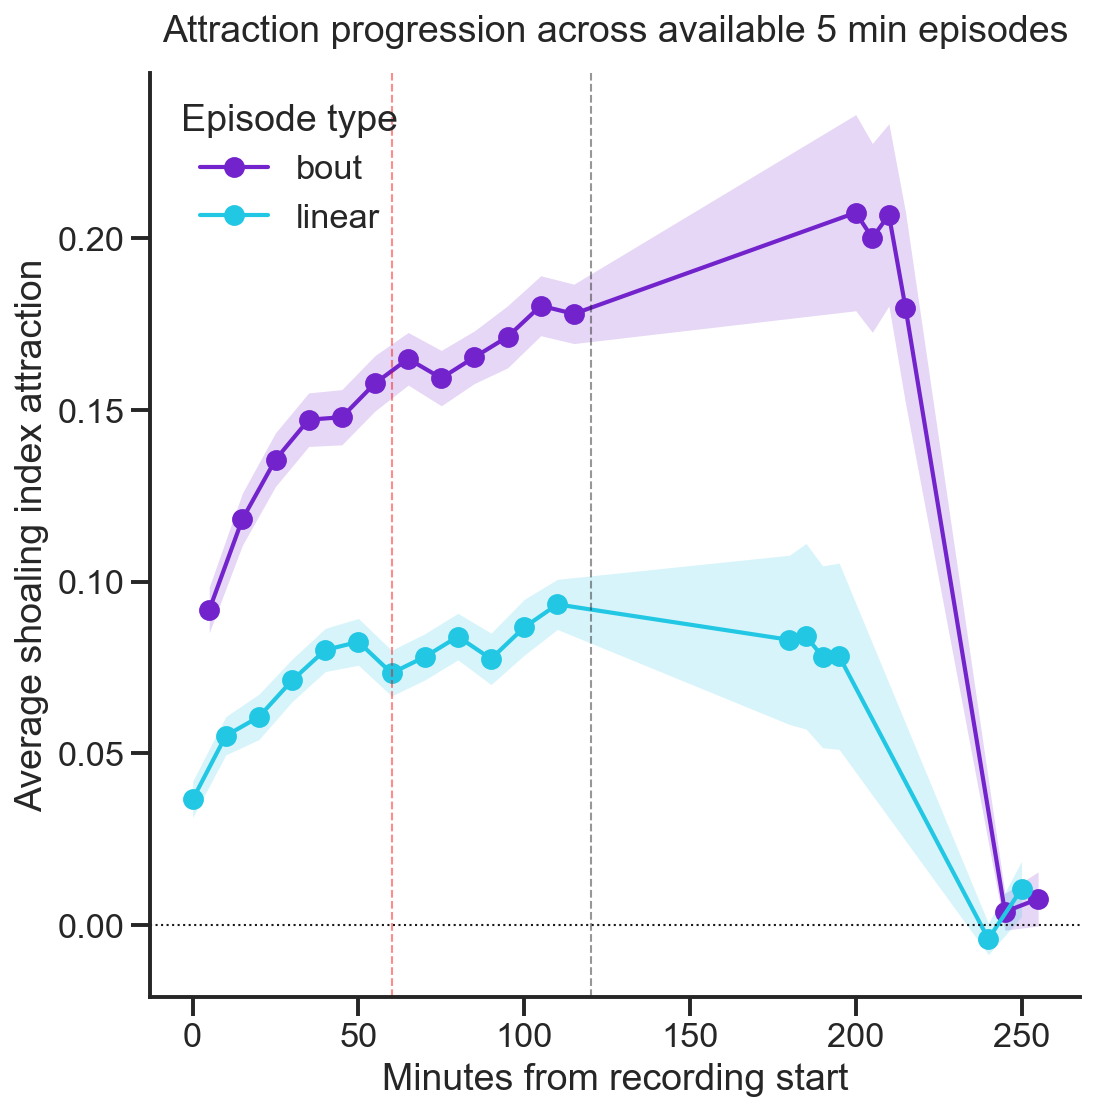

In [9]:
# Use only the full-window rows to visualize how attraction changes across the recording.
progression_source = df_plot.loc[df_plot['condition_key'] == FULL_CONDITION_KEY].copy()

# Average shoaling index by episode type and episode number, preserving the mean recording time for x-axis placement.
progression = (
    progression_source
    .groupby(['episode_type', 'episode_number'], as_index=False)
    .agg(
        recording_min=('recording_min', 'mean'),
        mean_si=('si', 'mean'),
        sem_si=('si', sem),
        n=('si', 'size'),
    )
    .sort_values(['episode_type', 'episode_number'])
)

# Create one time-course plot with bout and linear episode types overlaid.
fig, ax = plt.subplots(figsize=(8, 8))

for episode_type, dat in progression.groupby('episode_type', sort=False):
    # Draw the mean trajectory and a shaded +/- SEM band for this episode type.
    color = EPISODE_PALETTE.get(episode_type, None)
    ax.plot(
        dat['recording_min'],
        dat['mean_si'],
        marker='o',
        linewidth=2,
        label=episode_type,
        color=color,
    )
    ax.fill_between(
        dat['recording_min'],
        dat['mean_si'] - dat['sem_si'],
        dat['mean_si'] + dat['sem_si'],
        alpha=SEM_BAND_ALPHA,
        color=color,
        linewidth=0,
    )

# Mark the first-24-episode cutoff used to define the 2h comparison window.
ax.axvline(REFERENCE_MINUTE, ls='--', color=MIDPOINT_REFERENCE_COLOR, alpha=REFERENCE_LINE_ALPHA, linewidth=1)
ax.axvline(EPISODES_2H * EPISODE_DURATION_MIN, ls='--', color=WINDOW_CUTOFF_COLOR, alpha=REFERENCE_LINE_ALPHA, linewidth=1)
#ax.text(EPISODES_2H * EPISODE_DURATION_MIN, ax.get_ylim()[1], ' 24 episodes', va='top', ha='left')
# Finish plot styling, save the PDF, and show the first rows of the summarized table.
ax.axhline(0, ls=':', color=ZERO_BASELINE_COLOR, linewidth=1)
ax.set_xlabel('Minutes from recording start')
ax.set_ylabel('Average shoaling index attraction')
ax.set_title('Attraction progression across available 5 min episodes', pad=15)
ax.legend(title='Episode type', frameon=False)
sns.despine()
fig.savefig(outputDir / 'attraction_progression_2026_4h_all.pdf', bbox_inches='tight')
progression.head()


## 2h Progression Summary

Use only the first 24 five-minute episodes and plot the combined 2h time-course across experiments.

,episode_type,episode_number,recording_min,mean_si,sem_si,n
0,bout,2,5.0,0.091750,0.006624,236
1,bout,4,15.0,0.118183,0.007587,236
2,bout,6,25.0,0.135545,0.007806,236
3,bout,8,35.0,0.147164,0.007796,236
4,bout,10,45.0,0.147886,0.008040,236


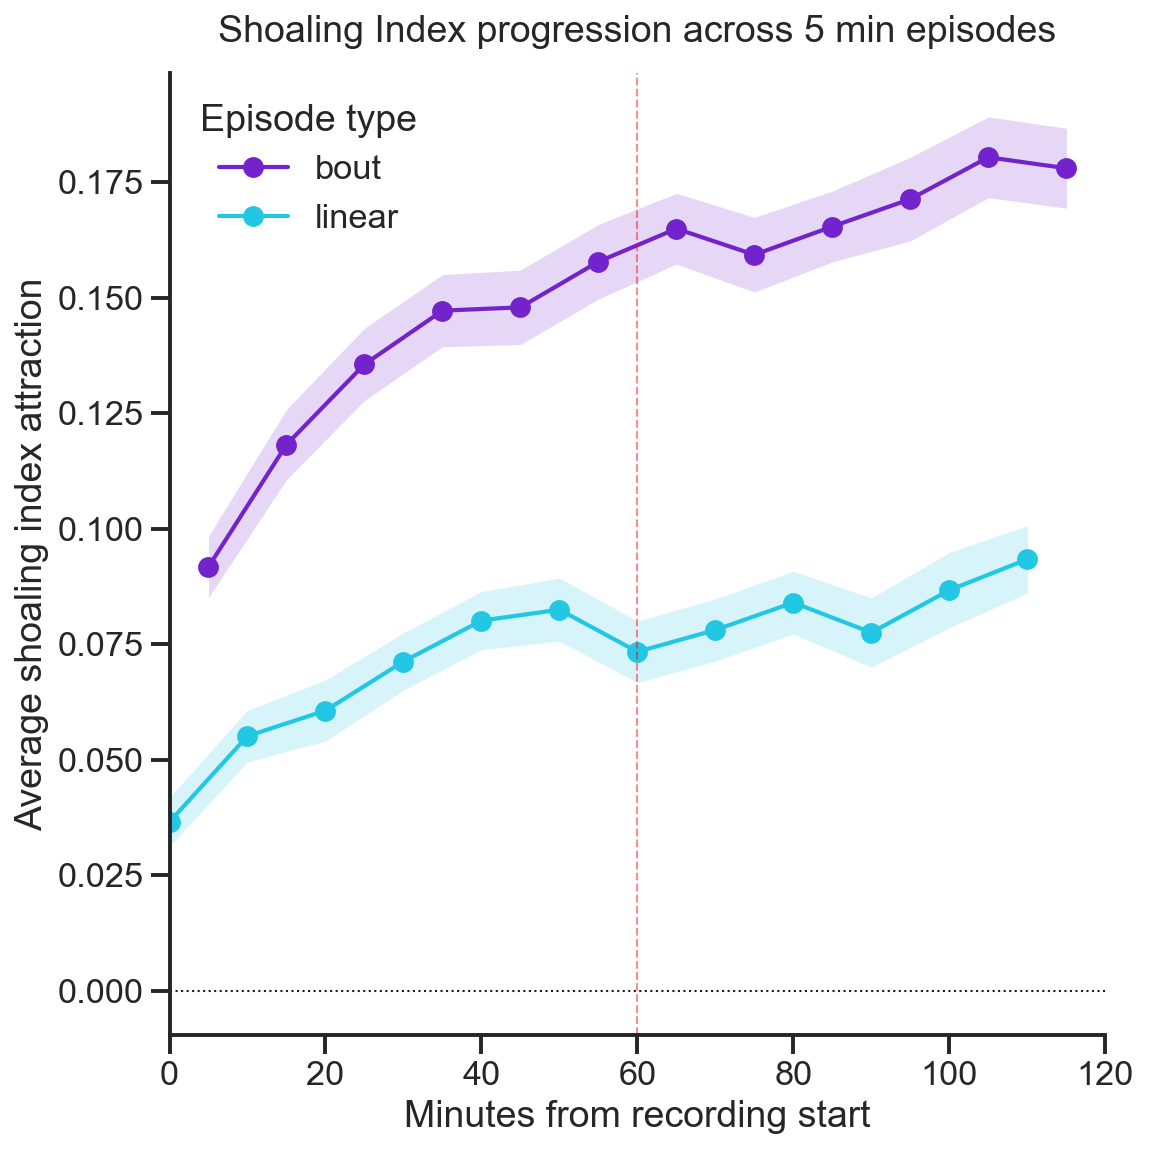

In [10]:
# Use only the derived 2h rows to visualize attraction across the 2h comparison window.
progression_2h_source = df_plot.loc[df_plot['condition_key'] == '2h'].copy()

# Average shoaling index by episode type and episode number, preserving the mean recording time for x-axis placement.
progression_2h = (
    progression_2h_source
    .groupby(['episode_type', 'episode_number'], as_index=False)
    .agg(
        recording_min=('recording_min', 'mean'),
        mean_si=('si', 'mean'),
        sem_si=('si', sem),
        n=('si', 'size'),
    )
    .sort_values(['episode_type', 'episode_number'])
)

# Create one 2h time-course plot with bout and linear episode types overlaid.
fig, ax = plt.subplots(figsize=(8, 8))

for episode_type, dat in progression_2h.groupby('episode_type', sort=False):
    # Draw the mean trajectory and a shaded +/- SEM band for this episode type.
    color = EPISODE_PALETTE.get(episode_type, None)
    ax.plot(
        dat['recording_min'],
        dat['mean_si'],
        marker='o',
        linewidth=2,
        label=episode_type,
        color=color,
    )
    ax.fill_between(
        dat['recording_min'],
        dat['mean_si'] - dat['sem_si'],
        dat['mean_si'] + dat['sem_si'],
        alpha=SEM_BAND_ALPHA,
        color=color,
        linewidth=0,
    )

# Mark the one-hour midpoint and the end of the 2h comparison window.
ax.axvline(REFERENCE_MINUTE, ls='--', color=MIDPOINT_REFERENCE_COLOR, alpha=REFERENCE_LINE_ALPHA, linewidth=1)
#ax.axvline(EPISODES_2H * EPISODE_DURATION_MIN, ls='--', color=WINDOW_CUTOFF_COLOR, alpha=REFERENCE_LINE_ALPHA, linewidth=1)
#ax.text(EPISODES_2H * EPISODE_DURATION_MIN, ax.get_ylim()[1], ' 24 episodes', va='top', ha='left')
# Finish plot styling, save the PDF, and show the first rows of the summarized table.
ax.axhline(0, ls=':', color=ZERO_BASELINE_COLOR, linewidth=1)
ax.set_xlim(0, EPISODES_2H * EPISODE_DURATION_MIN)
ax.set_xlabel('Minutes from recording start')
ax.set_ylabel('Average shoaling index attraction')
ax.set_title('Shoaling Index progression across 5 min episodes', pad=15)
ax.legend(title='Episode type', frameon=False)
sns.despine()
plt.tight_layout()
fig.savefig(outputDir / 'attraction_progression_2026_2h.pdf', bbox_inches='tight')
progression_2h.head()


## 2h Progression By Experiment

Use only the first 24 five-minute episodes and plot one time-course panel per experiment. Bout and linear episodes are drawn on the same axes for each experiment.

,experiment_label,date_dt,setup,episode_type,episode_number,recording_min,mean_si,sem_si,n
0,Sel1A_11-05-2026 setup 1,2026-05-11,1,bout,2,5.0,0.072098,0.016569,26
1,Sel1A_11-05-2026 setup 1,2026-05-11,1,bout,4,15.0,0.079052,0.022275,26
2,Sel1A_11-05-2026 setup 1,2026-05-11,1,bout,6,25.0,0.085352,0.016986,26
3,Sel1A_11-05-2026 setup 1,2026-05-11,1,bout,8,35.0,0.133522,0.025439,26
4,Sel1A_11-05-2026 setup 1,2026-05-11,1,bout,10,45.0,0.112814,0.019252,26


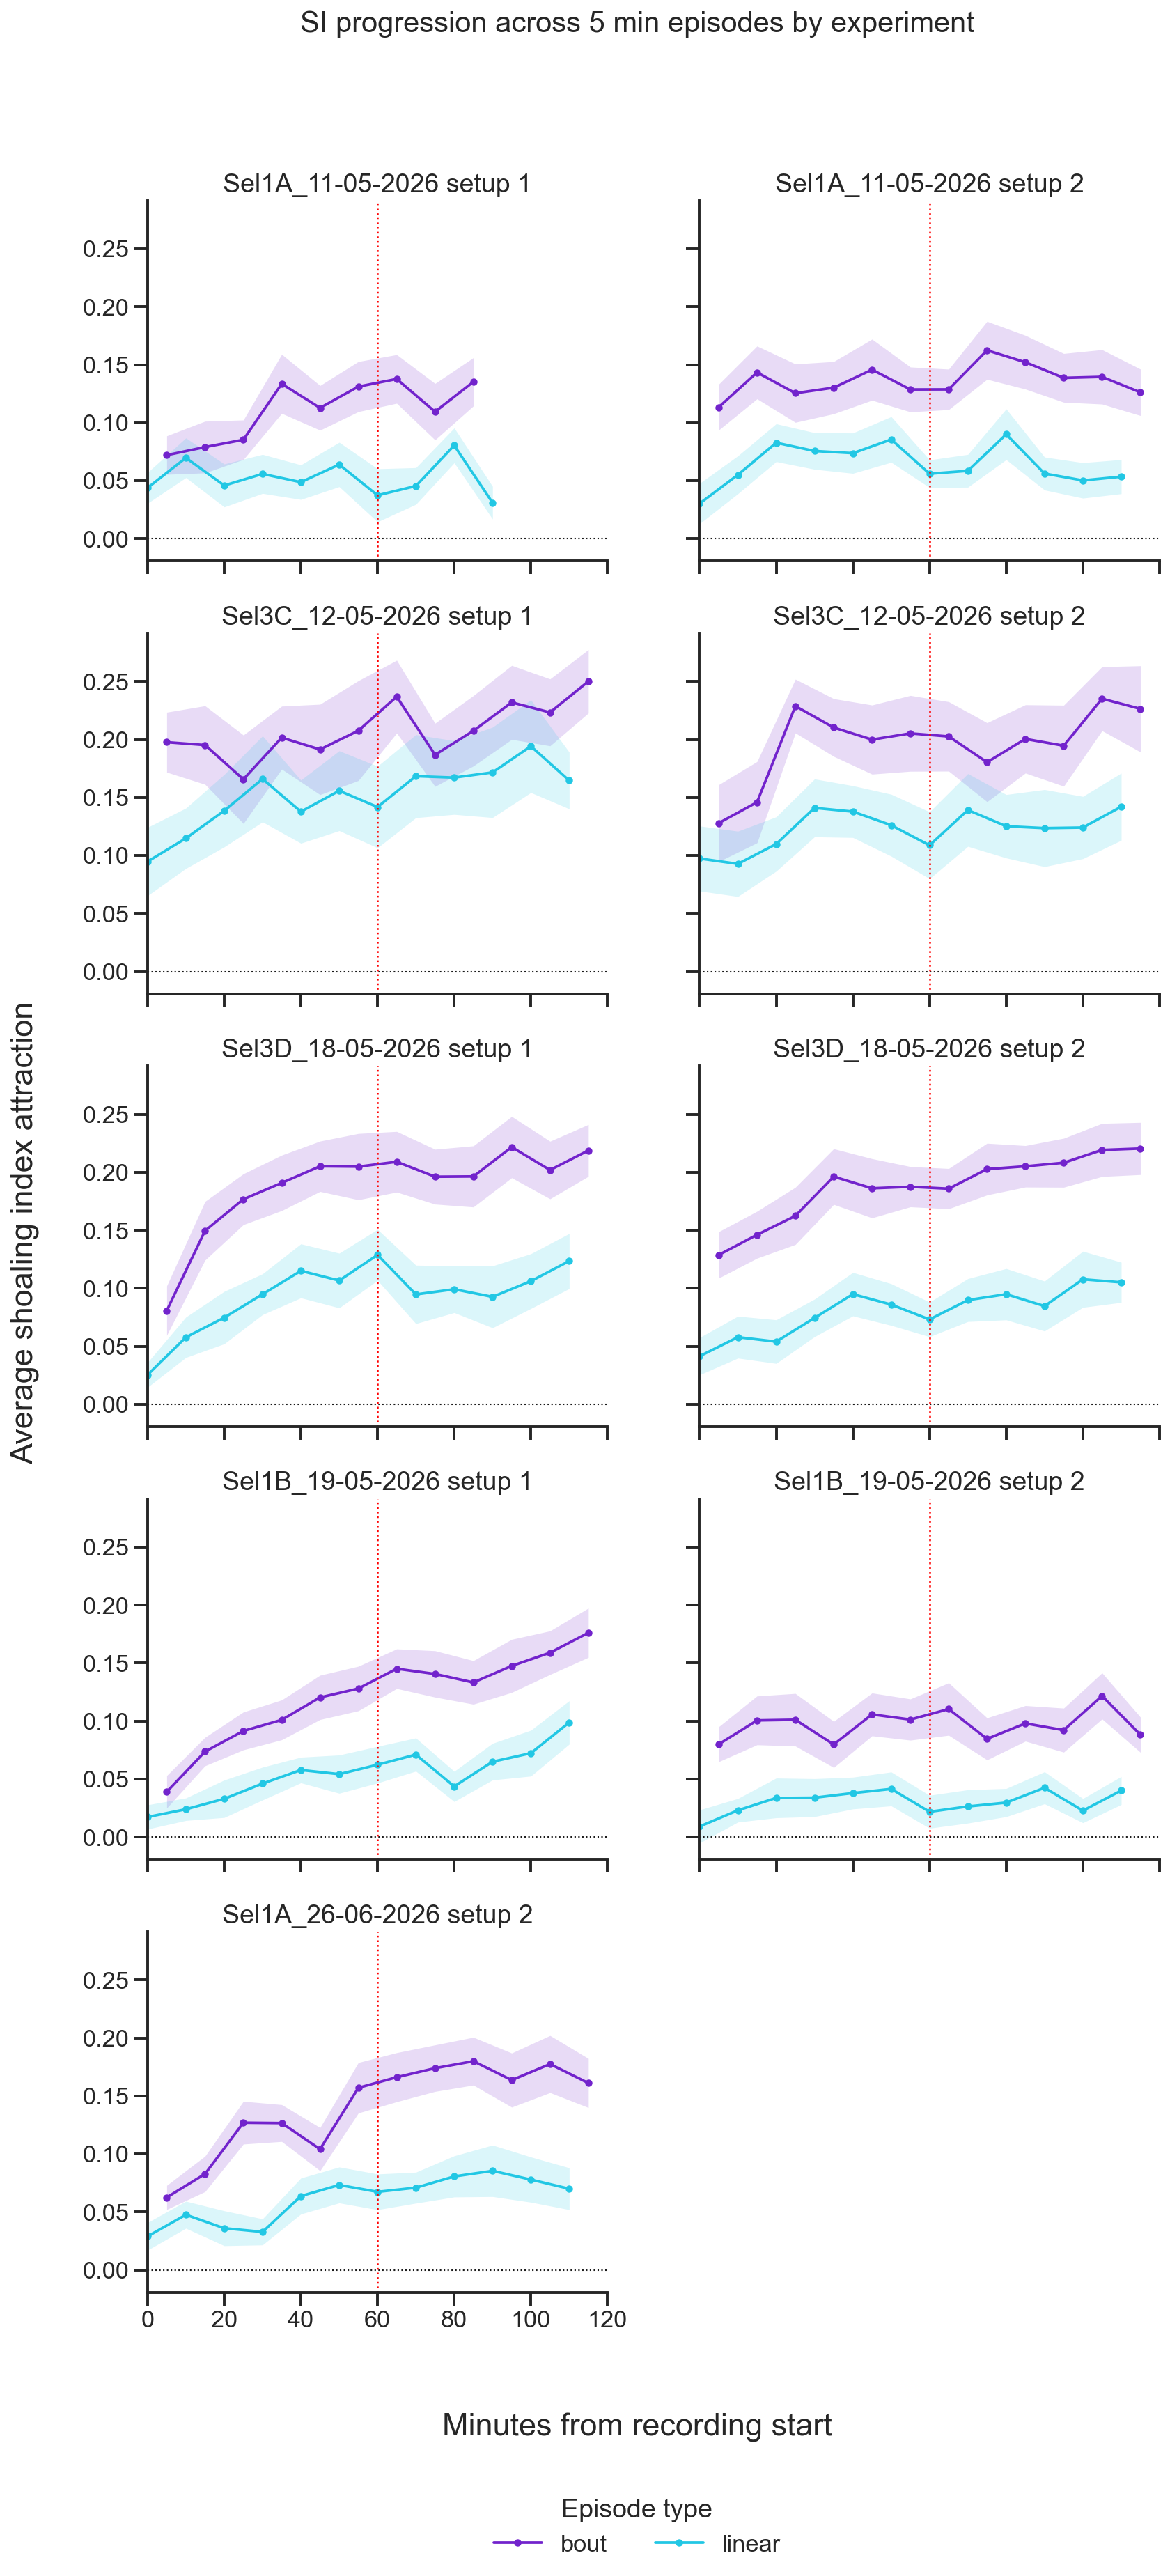

In [11]:
# Work from the derived 2h rows only; df_plot already excludes genotypes outside GENOTYPES.
progression_2h_source = df_plot.loc[df_plot['condition_key'] == '2h'].copy()

# The shared vertical reference marker uses REFERENCE_MINUTE and PER_EXPERIMENT_REFERENCE_LINE_STYLE from Settings.
# Build a readable panel label from the cohort/date label plus the recording setup.
progression_2h_source['experiment_label'] = (
    progression_2h_source['lineSet'].astype(str) + ' setup ' + progression_2h_source['setup'].astype(str)
)

# Collapse animal episode rows to one mean +/- SEM point per experiment, episode type, and 5-minute episode.
progression_2h_by_experiment = (
    progression_2h_source
    .groupby(['experiment_label', 'date_dt', 'setup', 'episode_type', 'episode_number'], as_index=False)
    .agg(
        recording_min=('recording_min', 'mean'),
        mean_si=('si', 'mean'),
        sem_si=('si', sem),
        n=('si', 'size'),
    )
    .sort_values(['date_dt', 'setup', 'episode_type', 'episode_number'])
)

# Keep subplot order chronological, with setup as the tie-breaker when multiple rows share a date.
experiment_order = (
    progression_2h_by_experiment[['experiment_label', 'date_dt', 'setup']]
    .drop_duplicates()
    .sort_values(['date_dt', 'setup'])
)

# Build a compact two-column grid with shared axes so panels are visually comparable.
n_experiments = len(experiment_order)
ncols = 2
nrows = int(np.ceil(n_experiments / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12.5, 5.2 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

# Draw one subplot per experiment; each subplot overlays bout and linear trajectories.
for ax, (_, experiment) in zip(axes, experiment_order.iterrows()):
    experiment_label = experiment['experiment_label']
    # Select only the summarized rows belonging to this panel's experiment label.
    experiment_dat = progression_2h_by_experiment.loc[
        progression_2h_by_experiment['experiment_label'] == experiment_label
    ]

    for episode_type, dat in experiment_dat.groupby('episode_type', sort=False):
        color = EPISODE_PALETTE.get(episode_type, None)
        # Mean shoaling-index trajectory for one episode type in this experiment.
        ax.plot(
            dat['recording_min'],
            dat['mean_si'],
            marker='o',
            linewidth=1.8,
            markersize=4,
            label=episode_type,
            color=color,
        )
        # Shaded band shows mean_si +/- standard error of the mean.
        ax.fill_between(
            dat['recording_min'],
            dat['mean_si'] - dat['sem_si'],
            dat['mean_si'] + dat['sem_si'],
            alpha=PER_EXPERIMENT_SEM_BAND_ALPHA,
            color=color,
            linewidth=0,
        )

    # Add the zero baseline and the editable vertical time marker to every visible panel.
    ax.axhline(0, ls=':', color=ZERO_BASELINE_COLOR, linewidth=1)
    ax.axvline(REFERENCE_MINUTE, **PER_EXPERIMENT_REFERENCE_LINE_STYLE)
    ax.set_title(experiment_label)

# Hide unused axes when the experiment count does not fill the last grid row.
for ax in axes[n_experiments:]:
    ax.set_visible(False)

# Limit the shared x-axis to the 2h window: 24 episodes x 5 minutes.
for ax in axes[:n_experiments]:
    ax.set_xlim(0, EPISODES_2H * EPISODE_DURATION_MIN)

# Use one shared legend and figure-level labels instead of repeating them in every panel.
handles, labels = axes[0].get_legend_handles_labels()

fig.supxlabel('Minutes from recording start', y=0.055)
fig.supylabel('Average shoaling index attraction')

fig.legend(
    handles,
    labels,
    title='Episode type',
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.005),
    ncol=2,
)

fig.suptitle('SI progression across 5 min episodes by experiment', fontsize = 20,y=0.95)
sns.despine(fig=fig)
#plt.tight_layout(rect=(0, 0.10, 1, 0.98))
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, title='Episode type', frameon=False, loc='lower center', bbox_to_anchor=(0.5, 0.035), ncol=2,)
# fig.supxlabel('Minutes from recording start')
# fig.supylabel('Average shoaling index attraction')
# fig.suptitle('SI progression across 5 min episodes by experiment', fontsize = 20, y=0.93)
# sns.despine(fig=fig)
# #plt.tight_layout(rect=(0, 0.07, 1, 0.96))
# Save the figure and display the first summarized rows as a quick data check.
fig.savefig(outputDir / 'attraction_progression_2026_2h_by_experiment.pdf', bbox_inches='tight')
progression_2h_by_experiment.head()
